# Line Tracing

Follow the yellow track line with three ideas: an **HSV color filter** isolates the line's pixels, their center gives the line's **offset** from image center, and **proportional steering** turns toward it. No learning, no model — classic robotics.

## [1] Setup

### 1.1. Talking to the car

The API takes radians; we work in degrees (+ = left). A speed command without `duration` expires after ~1 s (safety watchdog: a crashed program must not leave the car driving) — the drive loop re-sends it every frame, renewing the watchdog.

In [2]:
import os

DIR = "assets/line-tracing"
if not os.path.isdir(DIR):               # kernel cwd is the workspace root
    DIR = "examples/" + DIR

import math

import cv2
import numpy as np
import requests

BASE_URL = "http://localhost"


def camera():
    """Latest camera frame as a BGR image (ndarray)."""
    jpg = requests.get(f"{BASE_URL}/camera", timeout=2).content
    return cv2.imdecode(np.frombuffer(jpg, np.uint8), cv2.IMREAD_COLOR)


def drive(speed, steering):
    """speed in m/s, steering in degrees (+ = left). The API wants radians."""
    requests.post(f"{BASE_URL}/speed", json={"value": float(speed)}, timeout=2)
    requests.post(f"{BASE_URL}/steering",
                  json={"value": math.radians(steering)}, timeout=2)

/home/physicar/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


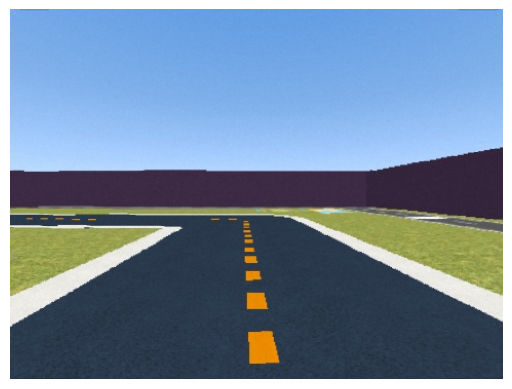

In [3]:
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(camera(), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## [2] Finding the line

### 2.1. The color filter

Convert to HSV (hue survives lighting changes far better than RGB), keep only pixels in the yellow range, and blank the top half (the line that matters is the road right in front). The mask's center of mass, normalized to −1..1, is the line offset. Fewer than 1000 yellow pixels = no line.

In [5]:
YELLOW_LO = (20, 80, 80)     # HSV range of the yellow line
YELLOW_HI = (35, 255, 255)


def find_line_offset(img):
    """Return the yellow line's horizontal offset from image center,
    normalized to [-1, 1] (None if no line is visible), plus the mask."""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, YELLOW_LO, YELLOW_HI)
    mask[:img.shape[0] // 2] = 0             # look at the lower half (near road)
    m = cv2.moments(mask)
    if m["m00"] < 1000:                       # too few yellow pixels
        return None, mask
    cx = m["m10"] / m["m00"]
    return (cx - img.shape[1] / 2) / (img.shape[1] / 2), mask

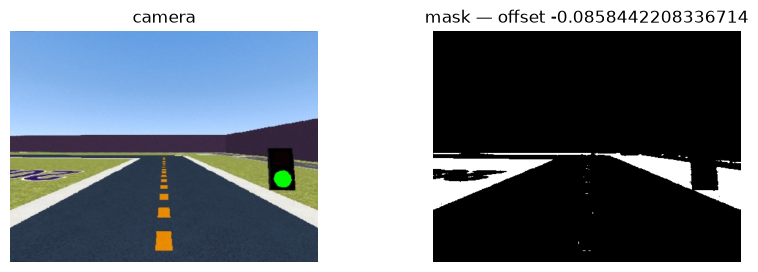

In [6]:
img = camera()
offset, mask = find_line_offset(img)

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax[0].set_title("camera")
ax[1].imshow(mask, cmap="gray"); ax[1].set_title(f"mask — offset {offset}")
for a in ax: a.axis("off")
plt.show()

### 2.2. Offset → steering

Proportional control: steer against the offset, harder the further the line drifts, clamped to the ±20° hardware limit. The minus sign: line to the right (positive offset) → steer right (negative). When the line is lost, creep forward at 0.3 m/s turning +15° until it reappears.

In [7]:
SPEED = 0.5            # m/s while the line is visible
STEER_GAIN = 20.0      # how hard to steer per unit of line offset

for offset in (-1.0, -0.5, 0.0, 0.5, 1.0):
    print(f"offset {offset:+.1f}  ->  steering {max(-20, min(20, -offset * STEER_GAIN)):+.1f} deg")

offset -1.0  ->  steering +20.0 deg
offset -0.5  ->  steering +10.0 deg
offset +0.0  ->  steering -0.0 deg
offset +0.5  ->  steering -10.0 deg
offset +1.0  ->  steering -20.0 deg


## [3] Drive

### 3.1. The live view

The web view is plumbing, not the logic — run the cell and forget it (the pages themselves live in the example's folder). It skips itself with a notice when port 5000 is already taken by another app.

In [8]:
"""Live web view (MYAPP tab, port 5000): the camera with every pixel that
passed the yellow filter repainted magenta -- exactly what the code steers
by -- plus the image center (white) and the detected line position (magenta)."""
import socket
import threading

_server = [None]     # the one live web view — a new serve() replaces it


def stop_view():
    if _server[0]:
        _server[0].shutdown()
        _server[0] = None


def _start(app):
    import logging
    logging.getLogger("werkzeug").setLevel(logging.ERROR)
    from werkzeug.serving import make_server
    stop_view()                      # one view at a time — replace the old one
    try:
        probe = socket.socket()                       # quiet pre-check: werkzeug
        probe.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)   # prints and
        probe.bind(("", 5000))                        # exits on a busy port
        probe.close()
        server = make_server("0.0.0.0", 5000, app, threaded=True)
    except (OSError, SystemExit):
        print("web view: port 5000 is in use by another example — "
              "interrupt (⏹) that cell or restart its kernel; "
              "continuing without the live view")
        return None
    _server[0] = server
    threading.Thread(target=server.serve_forever, daemon=True).start()
    print("web view: open the MYAPP tab to watch")
    return server

_frame = [b""]          # latest composited camera frame as JPEG
_status = [""]

_MAGENTA = (255, 0, 255)    # BGR -- a color that never occurs on the track


def update(img_bgr, mask, offset, steering, status):
    img = img_bgr.copy()
    img[mask > 0] = _MAGENTA    # the pixels the code actually steers by
    h, w = img.shape[:2]
    cv2.line(img, (w // 2, 0), (w // 2, h), (255, 255, 255), 1)
    if offset is not None:
        cx = int(w / 2 + offset * w / 2)
        cv2.line(img, (cx, 0), (cx, h), _MAGENTA, 2)
    _frame[0] = cv2.imencode(".jpg", img)[1].tobytes()
    _status[0] = status


def serve():
    from flask import Flask, Response, jsonify
    app = Flask(__name__)
    page = open(f"{DIR}/webui.html").read()   # presentation lives in the folder

    @app.get("/")
    def index():
        return page

    @app.get("/frame")
    def frame():
        return Response(_frame[0], mimetype="image/jpeg",
                        headers={"Cache-Control": "no-store"})

    @app.get("/data")
    def data():
        return jsonify({"status": _status[0]})

    return _start(app)

### 3.2. Follow the line

Runs until you interrupt the cell (⏹) — the `finally` block stops the car. Watch the **MYAPP tab** while it drives.

In [9]:
import time

serve()   # MYAPP tab: camera + mask + line offset, live
try:
    while True:
        t0 = time.time()
        img = camera()
        offset, mask = find_line_offset(img)

        if offset is None:
            steering = 15
            drive(0.3, steering)          # search: creep and turn
            status = "line lost — searching"
        else:
            steering = max(-20, min(20, -offset * STEER_GAIN))
            drive(SPEED, steering)
            status = f"offset {offset:+.2f}  steering {steering:+.1f}"
        update(img, mask, offset, steering, status)
        time.sleep(max(0.0, 1 / 15 - (time.time() - t0)))
except KeyboardInterrupt:
    pass
finally:
    drive(0, 0)
    stop_view()   # the live view lives and dies with this cell
    print("stopped")

web view: open the MYAPP tab to watch
stopped


In [11]:
def get_lidar():
    return requests.get(f"{BASE_URL}/lidar", timeout=2).json()


def avoid_offset(lidar, front_deg=40, danger_dist=0.5):
    ranges = lidar["ranges"]
    left_min = float("inf")
    right_min = float("inf")

    for deg in range(-front_deg, front_deg + 1):
        r = ranges.get(str(deg))
        if r is None or r <= 0:
            continue
        if deg >= 0:
            left_min = min(left_min, r)
        else:
            right_min = min(right_min, r)

    closest = min(left_min, right_min)
    if closest > danger_dist:
        return 0.0
    return 1.0 if left_min > right_min else -1.0

In [12]:
requests.get(f"{BASE_URL}/lidar").json()

{'step': 1.0,
 'count': 360,
 'range_min': 0.1,
 'range_max': 16.0,
 'ranges': {'-180': 3.582,
  '-179': 3.578,
  '-178': 3.578,
  '-177': 3.608,
  '-176': 3.582,
  '-175': 3.604,
  '-174': 1.352,
  '-173': 1.315,
  '-172': 1.295,
  '-171': 1.313,
  '-170': 1.318,
  '-169': 3.619,
  '-168': 3.652,
  '-167': 3.671,
  '-166': 3.685,
  '-165': 3.697,
  '-164': 3.731,
  '-163': 3.735,
  '-162': 3.747,
  '-161': 3.754,
  '-160': 3.802,
  '-159': 3.8,
  '-158': 3.737,
  '-157': 3.574,
  '-156': 3.445,
  '-155': 3.317,
  '-154': 3.193,
  '-153': 3.074,
  '-152': 2.972,
  '-151': 2.874,
  '-150': 2.786,
  '-149': 2.713,
  '-148': 2.617,
  '-147': 2.573,
  '-146': 2.518,
  '-145': 2.435,
  '-144': 2.381,
  '-143': 2.318,
  '-142': 2.26,
  '-141': 2.215,
  '-140': 2.15,
  '-139': 2.131,
  '-138': 2.089,
  '-137': 2.044,
  '-136': 2.006,
  '-135': 1.969,
  '-134': 1.939,
  '-133': 1.917,
  '-132': 1.883,
  '-131': 1.842,
  '-130': 1.828,
  '-129': 1.801,
  '-128': 1.796,
  '-127': 1.745,
  '-126'

In [13]:
lidar = get_lidar()
print(avoid_offset(lidar))

0.0


/home/physicar/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/physicar/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/physicar/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/physicar/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/physicar/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54889 (\N{HANGUL SYLLABLE HWANG}) missing from font(s) DejaV

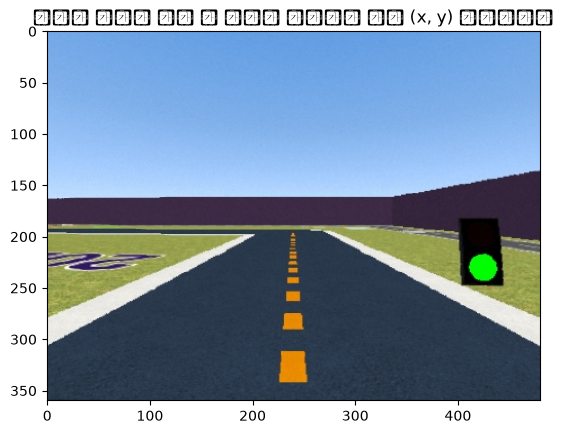

In [14]:
img = camera()
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("여기서 주황색 점선 위 좌표를 클릭해서 대충 (x, y) 확인하세요")
plt.show()

In [15]:
print(hsv[300, 400])  # 300, 400 자리에 방금 확인한 라인 위 좌표 넣기

[105 109  82]


In [16]:
print(hsv[320, 235])   # 세로(y)=320, 가로(x)=235
print(hsv[300, 240])   # 세로(y)=300, 가로(x)=240
print(hsv[260, 245])   # 세로(y)=260, 가로(x)=245

[ 17 253 235]
[111  91  76]
[ 18 222 219]


/home/physicar/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 55152 (\N{HANGUL SYLLABLE HYIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/physicar/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51004 (\N{HANGUL SYLLABLE EU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/physicar/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/physicar/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/physicar/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sa

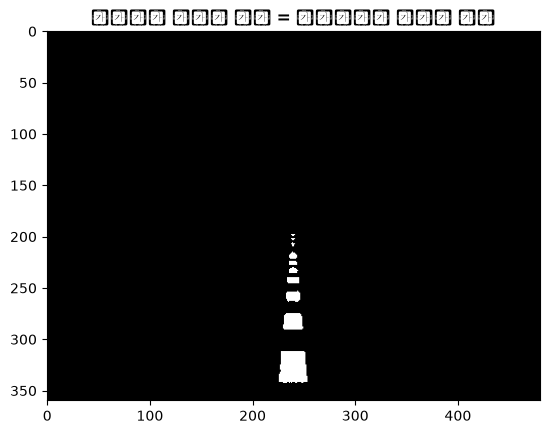

In [17]:
LINE_LO = (10, 150, 100)   # 색상 10~25도 사이, 어느 정도 진하고 밝은 것만
LINE_HI = (25, 255, 255)

mask = cv2.inRange(hsv, LINE_LO, LINE_HI)
mask[:img.shape[0] // 2] = 0   # 화면 위쪽 절반은 무시 (하늘, 먼 곳)

plt.imshow(mask, cmap="gray")
plt.title("흰색으로 보이는 부분 = 라인이라고 인식한 픽셀")
plt.show()

In [18]:
def find_line_offset(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, LINE_LO, LINE_HI)
    mask[:img.shape[0] // 2] = 0

    # 흰색 덩어리들을 하나하나 분리해서 이름표(번호) 붙이기
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)

    best_label = -1
    best_score = -1
    img_cx = img.shape[1] / 2

    for i in range(1, num_labels):  # 0번은 배경이라 제외
        x, y, w, h, area = stats[i]
        if area < 30:
            continue
        cx = centroids[i][0]
        # "화면 중앙에 가까울수록" + "세로로 길쭉할수록(라인다움)" 점수 주기
        closeness = 1.0 - abs(cx - img_cx) / img_cx
        elongation = h / max(w, 1)
        score = closeness * 2 + min(elongation, 3)
        if score > best_score:
            best_score = score
            best_label = i

    if best_label == -1:
        return None, mask

    # 라인이라고 뽑은 덩어리만 남긴 마스크로 다시 만들기
    line_mask = np.uint8(labels == best_label) * 255
    cx = centroids[best_label][0]
    return (cx - img_cx) / img_cx, line_mask

-0.002225806451612892


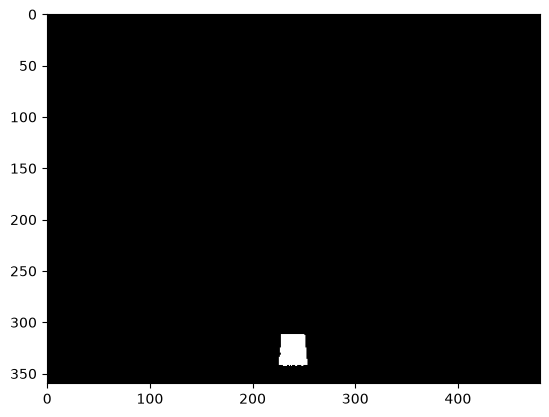

In [19]:
offset, line_mask = find_line_offset(img)
print(offset)
plt.imshow(line_mask, cmap="gray")
plt.show()

In [20]:
def curve_speed(offset, base_speed=0.5, min_speed=0.2):
    if offset is None:
        return min_speed
    sharpness = abs(offset)
    return base_speed - (base_speed - min_speed) * sharpness

In [31]:
import os, math, cv2, numpy as np, requests
BASE_URL = "http://localhost"

def camera():
    jpg = requests.get(f"{BASE_URL}/camera", timeout=2).content
    return cv2.imdecode(np.frombuffer(jpg, np.uint8), cv2.IMREAD_COLOR)

def drive(speed, steering):
    requests.post(f"{BASE_URL}/speed", json={"value": float(speed)}, timeout=2)
    requests.post(f"{BASE_URL}/steering", json={"value": math.radians(steering)}, timeout=2)

In [30]:
LINE_LO = (10, 150, 100)
LINE_HI = (25, 255, 255)

def find_line_offset(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, LINE_LO, LINE_HI)
    mask[:int(img.shape[0] * 0.35)] = 0
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)
    best_label, best_score = -1, -1
    img_cx = img.shape[1] / 2
    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        if area < 30:
            continue
        cx = centroids[i][0]
        closeness = 1.0 - abs(cx - img_cx) / img_cx
        elongation = h / max(w, 1)
        score = closeness * 2 + min(elongation, 3)
        if score > best_score:
            best_score, best_label = score, i
    if best_label == -1:
        return None, mask
    line_mask = np.uint8(labels == best_label) * 255
    cx = centroids[best_label][0]
    return (cx - img_cx) / img_cx, line_mask

In [29]:
def get_lidar():
    return requests.get(f"{BASE_URL}/lidar", timeout=2).json()

def avoid_offset(lidar, front_deg=40, danger_dist=0.5):
    ranges = lidar["ranges"]
    left_min, right_min = float("inf"), float("inf")
    for deg in range(-front_deg, front_deg + 1):
        r = ranges.get(str(deg))
        if r is None or r <= 0:
            continue
        if deg >= 0:
            left_min = min(left_min, r)
        else:
            right_min = min(right_min, r)
    closest = min(left_min, right_min)
    if closest > danger_dist:
        return 0.0
    return 1.0 if left_min > right_min else -1.0

In [28]:
def curve_speed(offset, base_speed=0.5, min_speed=0.2):
    if offset is None:
        return min_speed
    sharpness = abs(offset)
    return base_speed - (base_speed - min_speed) * sharpness

In [25]:
last_steer_sign = 1

In [33]:
SPEED = 0.5
STEER_GAIN = 20.0
AVOID_GAIN = 15.0

try:
    while True:
        img = camera()
        offset, line_mask = find_line_offset(img)

        if offset is not None:
            line_steer = max(-20, min(20, -offset * STEER_GAIN))
            last_steer_sign = 1 if line_steer > 0 else -1
            speed = curve_speed(offset, SPEED)
        else:
            line_steer = 20 * last_steer_sign
            speed = 0.2

        lidar = get_lidar()
        bias = avoid_offset(lidar)
        avoid_steer = bias * AVOID_GAIN
        if bias != 0.0:
            speed *= 0.6

        steering = max(-20, min(20, line_steer + avoid_steer))
        drive(speed, steering)
        print(f"offset={offset} steer={steering:.1f} speed={speed:.2f}")
except KeyboardInterrupt:
    drive(0, 0)
    print("멈췄어요")

offset=-0.010902031063321379 steer=0.2 speed=0.50
offset=-0.010902031063321379 steer=0.2 speed=0.50
offset=-0.010902031063321379 steer=0.2 speed=0.50
offset=-0.010902031063321379 steer=0.2 speed=0.50
offset=-0.010902031063321379 steer=0.2 speed=0.50
offset=-0.010902031063321379 steer=0.2 speed=0.50
offset=-0.010902031063321379 steer=0.2 speed=0.50
offset=-0.010902031063321379 steer=0.2 speed=0.50
offset=-0.010902031063321379 steer=0.2 speed=0.50
offset=-0.010357304387155134 steer=0.2 speed=0.50
offset=-0.010357304387155134 steer=0.2 speed=0.50
offset=-0.010357304387155134 steer=0.2 speed=0.50
offset=-0.010357304387155134 steer=0.2 speed=0.50
offset=-0.010357304387155134 steer=0.2 speed=0.50
offset=-0.010357304387155134 steer=0.2 speed=0.50
offset=-0.010357304387155134 steer=0.2 speed=0.50
offset=-0.010357304387155134 steer=0.2 speed=0.50
offset=-0.010357304387155134 steer=0.2 speed=0.50
offset=-0.010357304387155134 steer=0.2 speed=0.50
offset=-0.010357304387155134 steer=0.2 speed=0.50


In [32]:
session = requests.Session()

def camera():
    jpg = session.get(f"{BASE_URL}/camera", timeout=2).content
    return cv2.imdecode(np.frombuffer(jpg, np.uint8), cv2.IMREAD_COLOR)

def drive(speed, steering):
    session.post(f"{BASE_URL}/speed", json={"value": float(speed)}, timeout=2)
    session.post(f"{BASE_URL}/steering", json={"value": math.radians(steering)}, timeout=2)

def get_lidar():
    return session.get(f"{BASE_URL}/lidar", timeout=2).json()

smoothed_offset = 0.0
SMOOTH = 0.4  # 0에 가까울수록 부드러움(느리게 반응), 1이면 스무딩 없음

# 루프 안에서:
if offset is not None:
    smoothed_offset = SMOOTH * offset + (1 - SMOOTH) * smoothed_offset
    line_steer = max(-20, min(20, -smoothed_offset * STEER_GAIN))

In [24]:
def find_line_offset(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, LINE_LO, LINE_HI)
    mask[:int(img.shape[0] * 0.35)] = 0

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)
    best_label, best_score = -1, -1
    img_cx = img.shape[1] / 2
    img_h = img.shape[0]

    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        if area < 30:
            continue
        cx, cy = centroids[i]
        closeness = 1.0 - abs(cx - img_cx) / img_cx
        elongation = min(h / max(w, 1), 3)
        nearness = cy / img_h   # 화면 아래쪽(가까운 곳)일수록 1에 가까움
        score = closeness * 1.5 + elongation * 1.0 + nearness * 2.5  # 가까움에 제일 큰 비중
        if score > best_score:
            best_score, best_label = score, i

    if best_label == -1:
        return None, mask
    line_mask = np.uint8(labels == best_label) * 255
    cx = centroids[best_label][0]
    return (cx - img_cx) / img_cx, line_mask

In [25]:
def curve_speed(offset, base_speed=0.5, min_speed=0.15):
    if offset is None:
        return min_speed
    sharpness = abs(offset)
    if sharpness > 0.5:          # 급커브면 훨씬 더 느리게
        return min_speed
    return base_speed - (base_speed - min_speed) * sharpness

In [26]:
def find_line_bands(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, LINE_LO, LINE_HI)
    h, w = img.shape[:2]
    img_cx = w / 2

    def band_offset(y0, y1):
        band = mask.copy()
        band[:y0] = 0
        band[y1:] = 0
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(band)
        best_label, best_score = -1, -1
        for i in range(1, num_labels):
            x, y, ww, hh, area = stats[i]
            if area < 20:
                continue
            cx, cy = centroids[i]
            closeness = 1.0 - abs(cx - img_cx) / img_cx
            elongation = min(hh / max(ww, 1), 3)
            score = closeness * 1.5 + elongation
            if score > best_score:
                best_score, best_label = score, i
        if best_label == -1:
            return None
        return (centroids[best_label][0] - img_cx) / img_cx

    near = band_offset(int(h * 0.75), h)          # 바로 앞 (조향용)
    far = band_offset(int(h * 0.45), int(h * 0.75))  # 먼 곳 (커브 미리 알아채기용)
    return near, far

In [27]:
SPEED = 0.5
STEER_GAIN = 25.0        # 살짝 더 민감하게
AVOID_GAIN = 15.0
last_steer_sign = 1
smoothed_steer = 0.0
SMOOTH = 0.4

try:
    while True:
        img = camera()
        near, far = find_line_bands(img)
        curve_signal = far if far is not None else near   # 먼 곳 기준으로 속도 결정 (미리 감속)

        if near is not None:
            raw_steer = max(-20, min(20, -near * STEER_GAIN))
            last_steer_sign = 1 if raw_steer > 0 else -1
        elif far is not None:
            raw_steer = max(-20, min(20, -far * STEER_GAIN))  # 가까운 곳 안 보이면 먼 곳이라도 따라감
            last_steer_sign = 1 if raw_steer > 0 else -1
        else:
            raw_steer = 20 * last_steer_sign

        smoothed_steer = SMOOTH * raw_steer + (1 - SMOOTH) * smoothed_steer
        speed = curve_speed(curve_signal, SPEED, min_speed=0.12)  # 급커브면 훨씬 더 느리게

        lidar = get_lidar()
        bias = avoid_offset(lidar)
        avoid_steer = bias * AVOID_GAIN
        if bias != 0.0:
            speed *= 0.6

        steering = max(-20, min(20, smoothed_steer + avoid_steer))
        drive(speed, steering)
        print(f"near={near} far={far} steer={steering:.1f} speed={speed:.2f}")
except KeyboardInterrupt:
    drive(0, 0)
    print("멈췄어요")

near=0.036881101813110224 far=-0.0006410256410256683 steer=-0.4 speed=0.50
near=0.03696938065414059 far=-0.000694444444444405 steer=-0.6 speed=0.50
near=0.03696938065414059 far=-0.000694444444444405 steer=-0.7 speed=0.50
near=0.03696938065414059 far=-0.000694444444444405 steer=-0.8 speed=0.50
near=0.03696938065414059 far=-0.000694444444444405 steer=-0.9 speed=0.50
near=0.03758538251366126 far=0.0032051282051282232 steer=-0.9 speed=0.50
near=0.03758538251366126 far=0.0032051282051282232 steer=-0.9 speed=0.50
near=0.03758538251366126 far=0.0032051282051282232 steer=-0.9 speed=0.50
near=0.03758538251366126 far=0.0032051282051282232 steer=-0.9 speed=0.50
near=0.03851302460202603 far=-0.005324074074074048 steer=-0.9 speed=0.50
near=0.03851302460202603 far=-0.005324074074074048 steer=-1.0 speed=0.50
near=0.03851302460202603 far=-0.005324074074074048 steer=-1.0 speed=0.50
near=0.03851302460202603 far=-0.005324074074074048 steer=-1.0 speed=0.50
near=0.03851302460202603 far=-0.00532407407407404

In [ ]:
def curve_speed(offset, base_speed=0.5, min_speed=0.12):
    if offset is None:
        return min_speed
    sharpness = abs(offset)
    if sharpness > 0.3:
        return min_speed
    return base_speed - (base_speed - min_speed) * sharpness

In [28]:
lost_count = 0
search_dir = 1

In [29]:
MAX_JUMP = 0.15   # 한 프레임 사이에 이 값보다 더 크게 튀면 "의심스러움"
prev_offset = 0.0
pending_offset = None
pending_count = 0

def stabilize_offset(new_offset):
    """갑자기 확 튀는 값(오탐)을 걸러내는 함수.
    직전 값이랑 너무 다르면 바로 믿지 않고, 2프레임 연속 같은 값이 나와야 인정."""
    global prev_offset, pending_offset, pending_count

    if new_offset is None:
        return None

    jump = abs(new_offset - prev_offset)
    if jump < MAX_JUMP:
        # 정상적인 변화 -> 바로 인정
        prev_offset = new_offset
        pending_offset = None
        pending_count = 0
        return new_offset
    else:
        # 갑자기 확 튐 -> 의심하고 한 번 더 확인
        if pending_offset is not None and abs(new_offset - pending_offset) < MAX_JUMP:
            pending_count += 1
        else:
            pending_offset = new_offset
            pending_count = 1

        if pending_count >= 2:   # 2프레임 연속 같은 쪽이면 진짜 커브로 인정
            prev_offset = new_offset
            pending_offset = None
            pending_count = 0
            return new_offset
        else:
            # 아직 의심스러움 -> 이번 프레임은 직전 값 그대로 유지 (급하게 안 꺾음)
            return prev_offset

In [30]:
SPEED = 0.5
STEER_GAIN = 25.0
AVOID_GAIN = 15.0
last_steer_sign = 1
smoothed_steer = 0.0
SMOOTH = 0.4
lost_count = 0
search_dir = 1

try:
    while True:
        
        img = camera()
        near, far = find_line_bands(img)
        near = stabilize_offset(near)   # ← 이 한 줄 추가

        if near is not None:
            raw_steer = max(-20, min(20, -near * STEER_GAIN))
            last_steer_sign = 1 if raw_steer > 0 else -1
            lost_count = 0
            # far가 안 보이면 "급커브 진입 중"으로 간주해서 강제 감속
            curve_signal = far if far is not None else 1.0
            speed = curve_speed(curve_signal, SPEED, min_speed=0.12)
        elif far is not None:
            raw_steer = max(-20, min(20, -far * STEER_GAIN))
            last_steer_sign = 1 if raw_steer > 0 else -1
            lost_count = 0
            speed = 0.2
        else:
            lost_count += 1
            if lost_count > 15:          # 약 1초 넘게 못 찾으면
                if lost_count % 20 == 0:  # 일정 시간마다 반대 방향으로 바꿔서 시도
                    search_dir *= -1
                raw_steer = 20 * search_dir
                speed = 0.1               # 아주 천천히, 조심스럽게 찾기
            else:
                raw_steer = 20 * last_steer_sign
                speed = 0.15

        smoothed_steer = SMOOTH * raw_steer + (1 - SMOOTH) * smoothed_steer

        lidar = get_lidar()
        bias = avoid_offset(lidar)
        avoid_steer = bias * AVOID_GAIN
        if bias != 0.0:
            speed *= 0.6

        steering = max(-20, min(20, smoothed_steer + avoid_steer))
        drive(speed, steering)
        print(f"near={near} far={far} steer={steering:.1f} speed={speed:.2f} lost={lost_count}")
except KeyboardInterrupt:
    drive(0, 0)
    print("멈췄어요")

near=None far=0.032666666666666684 steer=-0.3 speed=0.20 lost=0
near=None far=0.032666666666666684 steer=-0.5 speed=0.20 lost=0
near=None far=0.032666666666666684 steer=-0.6 speed=0.20 lost=0
near=None far=0.032666666666666684 steer=-0.7 speed=0.20 lost=0
near=None far=0.032666666666666684 steer=-0.8 speed=0.20 lost=0
near=None far=0.03146551724137936 steer=-0.8 speed=0.20 lost=0
near=None far=0.03146551724137936 steer=-0.8 speed=0.20 lost=0
near=None far=0.03146551724137936 steer=-0.8 speed=0.20 lost=0
near=None far=0.03146551724137936 steer=-0.8 speed=0.20 lost=0
near=None far=0.03146551724137936 steer=-0.8 speed=0.20 lost=0
near=None far=0.03146551724137936 steer=-0.8 speed=0.20 lost=0
near=None far=0.03146551724137936 steer=-0.8 speed=0.20 lost=0
near=None far=0.03146551724137936 steer=-0.8 speed=0.20 lost=0
near=None far=0.03253205128205134 steer=-0.8 speed=0.20 lost=0
near=None far=0.03253205128205134 steer=-0.8 speed=0.20 lost=0
near=None far=0.03253205128205134 steer=-0.8 speed

In [32]:
import hashlib

last_frame_hash = None
last_stable_near = 0.0

def read_camera():
    """카메라 사진을 받아오면서, 그 사진의 '지문'(해시)도 같이 계산"""
    jpg = session.get(f"{BASE_URL}/camera", timeout=2).content
    frame_hash = hashlib.md5(jpg).hexdigest()
    img = cv2.imdecode(np.frombuffer(jpg, np.uint8), cv2.IMREAD_COLOR)
    return img, frame_hash

In [33]:
import os, math, cv2, numpy as np, requests, hashlib

BASE_URL = "http://localhost"
session = requests.Session()

def read_camera():
    """카메라 사진을 받아오면서, 사진이 진짜 바뀌었는지 확인용 '지문'도 같이 반환"""
    jpg = session.get(f"{BASE_URL}/camera", timeout=2).content
    frame_hash = hashlib.md5(jpg).hexdigest()
    img = cv2.imdecode(np.frombuffer(jpg, np.uint8), cv2.IMREAD_COLOR)
    return img, frame_hash

def drive(speed, steering):
    session.post(f"{BASE_URL}/speed", json={"value": float(speed)}, timeout=2)
    session.post(f"{BASE_URL}/steering", json={"value": math.radians(steering)}, timeout=2)

def get_lidar():
    return session.get(f"{BASE_URL}/lidar", timeout=2).json()

In [34]:
LINE_LO = (10, 150, 100)
LINE_HI = (25, 255, 255)

def find_line_bands(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, LINE_LO, LINE_HI)
    h, w = img.shape[:2]
    img_cx = w / 2

    def band_offset(y0, y1):
        band = mask.copy()
        band[:y0] = 0
        band[y1:] = 0
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(band)
        best_label, best_score = -1, -1
        for i in range(1, num_labels):
            x, y, ww, hh, area = stats[i]
            if area < 20:
                continue
            cx, cy = centroids[i]
            closeness = 1.0 - abs(cx - img_cx) / img_cx
            elongation = min(hh / max(ww, 1), 3)
            score = closeness * 1.5 + elongation
            if score > best_score:
                best_score, best_label = score, i
        if best_label == -1:
            return None
        return (centroids[best_label][0] - img_cx) / img_cx

    near = band_offset(int(h * 0.75), h)
    far = band_offset(int(h * 0.45), int(h * 0.75))
    return near, far

In [35]:
def avoid_offset(lidar, front_deg=40, danger_dist=0.5):
    ranges = lidar["ranges"]
    left_min, right_min = float("inf"), float("inf")
    for deg in range(-front_deg, front_deg + 1):
        r = ranges.get(str(deg))
        if r is None or r <= 0:
            continue
        if deg >= 0:
            left_min = min(left_min, r)
        else:
            right_min = min(right_min, r)
    closest = min(left_min, right_min)
    if closest > danger_dist:
        return 0.0
    return 1.0 if left_min > right_min else -1.0

In [36]:
def curve_speed(offset, base_speed=0.5, min_speed=0.12):
    if offset is None:
        return min_speed
    sharpness = abs(offset)
    if sharpness > 0.3:
        return min_speed
    return base_speed - (base_speed - min_speed) * sharpness

In [37]:
MAX_JUMP = 0.15
prev_offset = 0.0
pending_offset = None
pending_count = 0

def stabilize_offset(new_offset):
    global prev_offset, pending_offset, pending_count
    if new_offset is None:
        return None
    jump = abs(new_offset - prev_offset)
    if jump < MAX_JUMP:
        prev_offset = new_offset
        pending_offset = None
        pending_count = 0
        return new_offset
    else:
        if pending_offset is not None and abs(new_offset - pending_offset) < MAX_JUMP:
            pending_count += 1
        else:
            pending_offset = new_offset
            pending_count = 1
        if pending_count >= 2:
            prev_offset = new_offset
            pending_offset = None
            pending_count = 0
            return new_offset
        else:
            return prev_offset

In [46]:
SPEED = 0.5
STEER_GAIN = 25.0
AVOID_GAIN = 15.0
last_steer_sign = 1
smoothed_steer = 0.0
SMOOTH = 0.4
lost_count = 0
search_dir = 1
last_frame_hash = None
last_stable_near = 0.0
committed_dir = 1   # "확실하게 꺾던 방향" — 노이즈로는 안 바뀜

In [48]:
session.post(f"{BASE_URL}/camera/tilt", json={"value": math.radians(-25)})

<Response [200]>

In [49]:
try:
    while True:
        img, frame_hash = read_camera()
        is_new_frame = (frame_hash != last_frame_hash)
        last_frame_hash = frame_hash

        near, far = find_line_bands(img)

        if is_new_frame:
            near = stabilize_offset(near)
            last_stable_near = near
        else:
            near = last_stable_near

        if near is not None:
            raw_steer = max(-20, min(20, -near * STEER_GAIN))
            last_steer_sign = 1 if raw_steer > 0 else -1
            if abs(near) > 0.01:          # 노이즈 수준(0.01 미만)이 아니라 확실한 신호일 때만
                 committed_dir = last_steer_sign    # "진짜 방향"으로 기억 갱신
            lost_count = 0
            curve_signal = far if far is not None else 1.0
            speed = curve_speed(curve_signal, SPEED, min_speed=0.12)

        elif far is not None:
            raw_steer = max(-20, min(20, -far * STEER_GAIN))
            last_steer_sign = 1 if raw_steer > 0 else -1
            lost_count = 0
            speed = 0.2
        else:
            lost_count += 1
            if lost_count > 15:
                if lost_count % 20 == 0:
                    search_dir *= -1
                raw_steer = 20 * search_dir
                speed = 0.1
            else:
                raw_steer = 20 * last_steer_sign
                speed = 0.15

        predictive_bias = 0.0
        if far is None and near is not None:
            predictive_bias = committed_dir * 8.0   # ← last_steer_sign 대신 committed_dir
        raw_steer = max(-20, min(20, raw_steer + predictive_bias))

        smoothed_steer = SMOOTH * raw_steer + (1 - SMOOTH) * smoothed_steer

        lidar = get_lidar()
        bias = avoid_offset(lidar)
        avoid_steer = bias * AVOID_GAIN
        if bias != 0.0:
            speed *= 0.6

        steering = max(-20, min(20, smoothed_steer + avoid_steer))
        drive(speed, steering)
        print(f"new_frame={is_new_frame} near={near} far={far} pred_bias={predictive_bias:.1f} raw_steer={raw_steer:.1f} steer={steering:.1f} speed={speed:.2f} lost={lost_count}")
except KeyboardInterrupt:
    drive(0, 0)
    print("멈췄어요")

new_frame=True near=-0.0013922847052430854 far=-0.0014009243212016762 pred_bias=0.0 raw_steer=0.0 steer=10.9 speed=0.50 lost=0
new_frame=False near=-0.0013922847052430854 far=-0.0014009243212016762 pred_bias=0.0 raw_steer=0.0 steer=6.6 speed=0.50 lost=0
new_frame=False near=-0.0013922847052430854 far=-0.0014009243212016762 pred_bias=0.0 raw_steer=0.0 steer=3.9 speed=0.50 lost=0
new_frame=True near=-0.0014511963023381943 far=-0.0013237847222222618 pred_bias=0.0 raw_steer=0.0 steer=2.4 speed=0.50 lost=0
new_frame=False near=-0.0014511963023381943 far=-0.0013237847222222618 pred_bias=0.0 raw_steer=0.0 steer=1.4 speed=0.50 lost=0
new_frame=False near=-0.0014511963023381943 far=-0.0013237847222222618 pred_bias=0.0 raw_steer=0.0 steer=0.9 speed=0.50 lost=0
new_frame=False near=-0.0014511963023381943 far=-0.0013237847222222618 pred_bias=0.0 raw_steer=0.0 steer=0.5 speed=0.50 lost=0
new_frame=True near=0.023951715374841125 far=0.01941884280593958 pred_bias=0.0 raw_steer=-0.6 steer=0.1 speed=0.

In [50]:
session.post(f"{BASE_URL}/camera/tilt", json={"value": math.radians(-25)})

<Response [200]>

In [52]:
print(session.get(f"{BASE_URL}/camera/tilt").json())

-0.4363323129985824


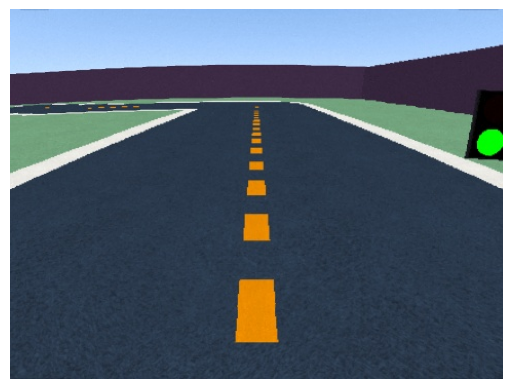

In [54]:
drive(0.1, 0)      # 아주 살짝 움직여서 시뮬레이터가 새로 렌더링하게 만들기
time.sleep(0.3)
drive(0, 0)         # 다시 정지

img = camera()
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [55]:
session.post(f"{BASE_URL}/camera/tilt", json={"value": math.radians(-30)})  # 문서상 최대 ±30도

<Response [200]>

현재 틸트: -0.5235987755982988


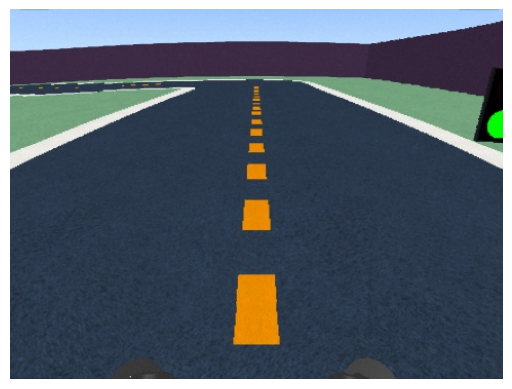

In [56]:
print("현재 틸트:", session.get(f"{BASE_URL}/camera/tilt").json())
img = camera()
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

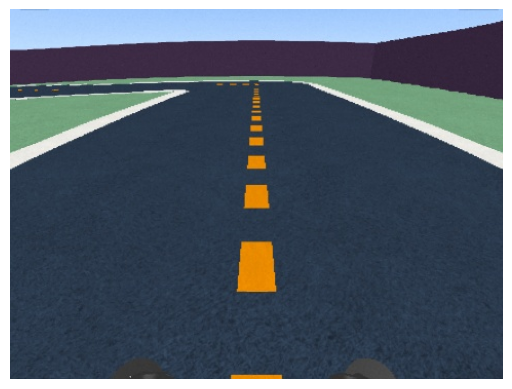

In [57]:
session.post(f"{BASE_URL}/camera/tilt", json={"value": math.radians(-30)})
for i in range(10):
    drive(0.2, 0)
    time.sleep(0.1)
img = camera()   # 계속 움직이는 도중에 캡처
drive(0, 0)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()